<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-2-MateuszOlech/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [ ]:
# wczytanie zbioru danych
titanic = pd.read_csv("/content/train.csv")
titanic

#titanic.shape

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# MIEJSCE NA TWÓJ KOD
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


PassengerId - Id pasażera, unikatowe wartości, prawdopodobnie bez znaczenia dla korelacji

Survived - czy przeżył; 1 - Tak, 0 - Nie

Pclass - rodzaj klasy jaką podróżował; zakres (1-3)

Name - Dane osobowe, raczej bez przyszłego zastosowania

Sex - płeć, wartość tekstowa

Age - wiek pasażera (trochę brakuje)

SibSp - ile rodzeństwa/współmałżonków było na pokładzie

Parch - ile rodziców/dzieci było na pokładzie

Ticket - numer biletu, raczej bez późniejszej przydatności

Fare - ile zapłacono za bilet

Cabin - numer kabiny, dużo pustych, prawdopodobnie nie da się zastosować w sprawdzaniu korelacji

Embarked - port zaokrętowania

## Przekształcenie danych

In [ ]:
# MIEJSCE NA TWÓJ KOD
#Zaimplementowane pod uzupełnieniem brakujących danych

## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

<Axes: xlabel='Age', ylabel='Count'>

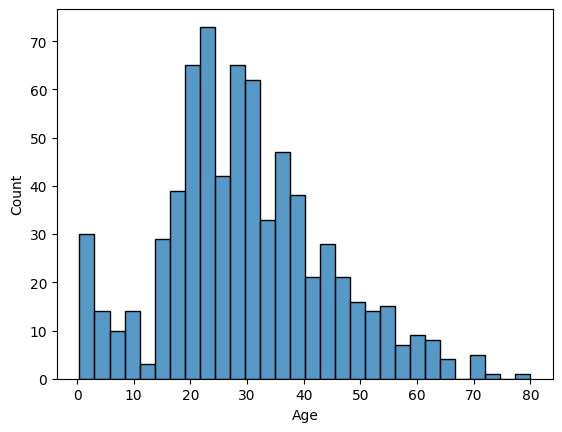

In [ ]:
# MIEJSCE NA TWÓJ KOD
titanic = pd.read_csv("/content/train.csv")
sns.histplot(titanic['Age'], bins=30)

Wiek pasażerów jest zróżnicowany, wartością najlepiej oddającą wiek losowego pasażera powinna być mediana

In [ ]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

In [ ]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [ ]:
# MIEJSCE NA TWÓJ KOD
titanic['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
print(titanic['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


W przypadku zaokrętowania, mamy trzy możliwe wartości, z czego jedna zdecydowania przeważa nad pozostałymi. Dlatego najlepszym uzupełnieniem brakujących wierszy będzie uzupełnienie ich najczęstszą wartością

In [ ]:
titanic['Embarked'] = titanic['Embarked'].fillna('S')

In [ ]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

Ponad 70% wierszy jest pustych, oraz nie ma schematu, który pozwalałby na w miarę bezpieczne uzupełnienie brakujących wartości w tej kolumnie. Dlatego jedynym logicznym rozwiązaniem jest usunięcię tej kolumny.

In [ ]:
# MIEJSCE NA TWÓJ KOD
titanic = titanic.drop(columns=['Cabin'])

In [ ]:
#assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [ ]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

In [ ]:
# PRZEKSZTAŁCANIE DANYCH
ages = [0, 12, 21, 41, 61, 100]
categories = ['0-11', '12-20', '21-40', '41-60', '61+']
titanic['Age_category'] = pd.cut(titanic['Age'], bins=ages, labels=categories)

titanic['Has_parch'] = titanic['Parch'] > 0

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

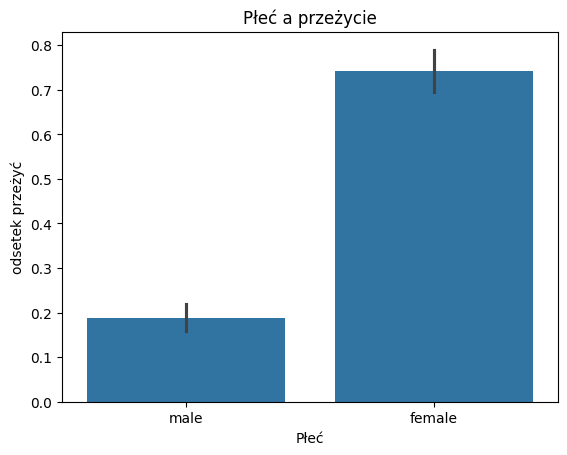

In [ ]:
# MIEJSCE NA TWÓJ KOD
sns.barplot(data=titanic, x='Sex', y='Survived')
plt.title('Płeć a przeżycie')
plt.xlabel('Płeć')
plt.ylabel('odsetek przeżyć')
plt.show()

Text(0, 0.5, '')

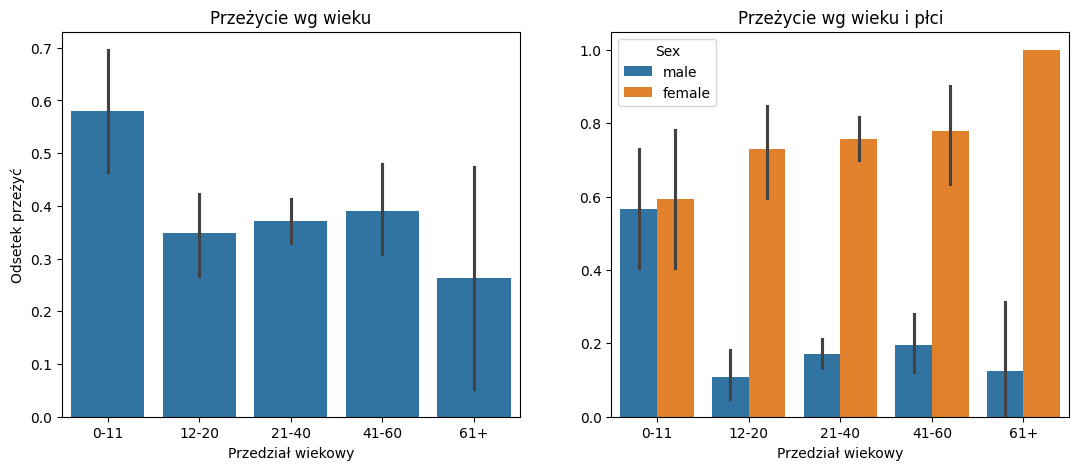

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=titanic, x='Age_category', y='Survived', ax=axes[0])
axes[0].set_title('Przeżycie wg wieku')
axes[0].set_xlabel('Przedział wiekowy')
axes[0].set_ylabel('Odsetek przeżyć')

sns.barplot(data=titanic, x='Age_category', y='Survived', hue='Sex', ax=axes[1])
axes[1].set_title('Przeżycie wg wieku i płci')
axes[1].set_xlabel('Przedział wiekowy')
axes[1].set_ylabel('')

Text(0, 0.5, 'Podział wiekowy')

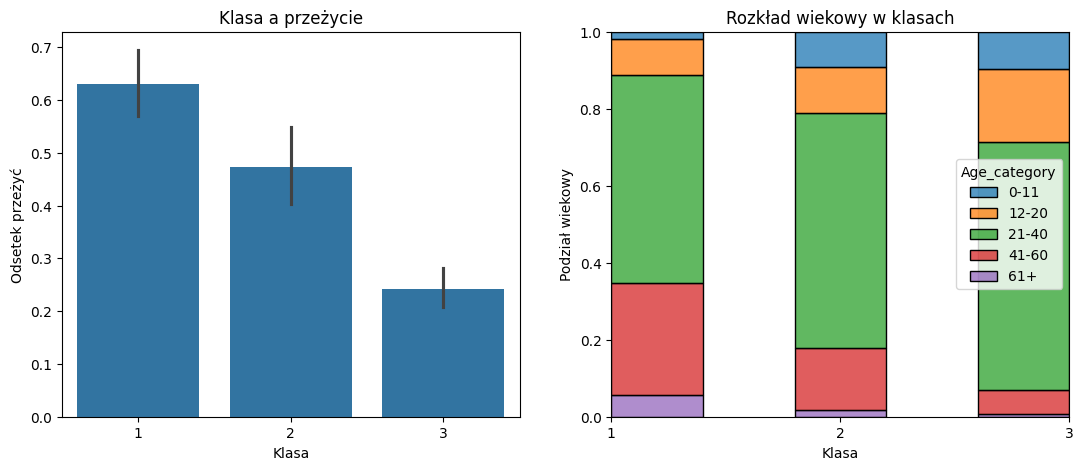

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=titanic, x='Pclass', y='Survived', ax=axes[0])
axes[0].set_title('Klasa a przeżycie')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Odsetek przeżyć')

sns.histplot(data=titanic, x='Pclass', hue='Age_category', multiple='fill', bins=5, ax=axes[1])
axes[1].set_xticks([1, 2, 3])
axes[1].set_title('Rozkład wiekowy w klasach')
axes[1].set_xlabel('Klasa')
axes[1].set_ylabel('Podział wiekowy')

Text(0.5, 1.0, 'Wpływ rodzica/dziecka na przeżycie wg płci')

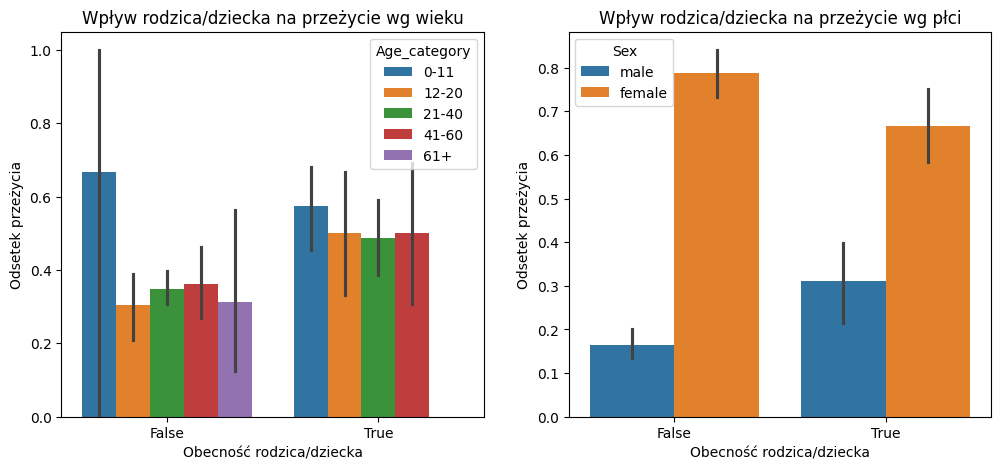

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(
    data=titanic,
    x='Has_parch',
    y='Survived',
    hue='Age_category',
    ax=axes[0]
)
axes[0].set_ylabel('Odsetek przeżycia')
axes[0].set_xlabel('Obecność rodzica/dziecka')
axes[0].set_title('Wpływ rodzica/dziecka na przeżycie wg wieku')

sns.barplot(
    data=titanic,
    x='Has_parch',
    y='Survived',
    hue='Sex',
    ax=axes[1]
)
axes[1].set_ylabel('Odsetek przeżycia')
axes[1].set_xlabel('Obecność rodzica/dziecka')
axes[1].set_title('Wpływ rodzica/dziecka na przeżycie wg płci')

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

1. Płeć a przeżycie
 - Zdecydowaną większość osób, które przeżyły katastrofę, stanowiły kobiety – ponad 70%.
 - W każdej kategorii wiekowej (poza dziećmi) odsetek uratowanych kobiet był znacznie większy niż mężczyzn.

2. Wiek a przeżycie
- Dzieci do 12 roku życia miały największe szanse przeżycia.
- Osoby młode (13–25 lat) miały około 35% szans na przetrwanie.
- Odsetek przeżycia w starszych grupach nieznacznie wzrastał, co wynikało z faktu, że starsi pasażerowie częściej podróżowali w wyższych klasach.

3. Klasa a przeżycie
- Pasażerowie 1 klasy mieli ponad 60% szans na przeżycie.
- Osoby z 3 klasy miały szansę ponad dwukrotnie mniejszą, co pokazuje duży wpływ pozycji społecznej i dostępu do łodzi ratunkowych.

4. Obecność rodziny a przeżycie
- Pasażerowie, którzy mieli na pokładzie dziecko lub rodzica, mieli większe szanse na przeżycie niż osoby samotne.
- Efekt ten był szczególnie widoczny w przypadku osób w przedziale wiekowym 12-60 i mężczyzn

In [ ]:
# MIEJSCE NA TWÓJ KOD

# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [39]:
spotify = pd.read_csv("/content/dataset.csv")
spotify
#spotify.shape

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [40]:
# MIEJSCE NA TWÓJ KOD
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [41]:
spotify.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


track_id - Id ścieżki (powtarzają się)

artists - wykonawcy (może być kilku, warto później rozdzielić po ;), 1 brakuje

album_name - nazwa albumu, 1 brakuje

track_name - nazwa ścieżki, 1 brakuje

popularity - popularność ścieżki w skali 1-100

duration_ms - długość ścieżki w ms

explicit - czy zawiera wulgarne słownictwo (True lub False)

danceability - jak bardzo ścieżka umożliwia taniec (w skali od 0 do 1)

energy - jak bardzo energiczna jest ścieżka (w skali 0.0 do 1.0)

key - klucz tonacji utworu (-1 jeśli nie wykryto)

loudness - jak głośny jest utwór w dB

mode - tonacja durowa (1) lub molowa (0)

speechiness - obecność mowy w ścieżce (trzy główne przedziały: <0.33 - przede wszystkim muzyka, 0.33-0.66 - zarówno muzyka jak i mowa, >0.66 - audycje mówione)

acousticness - w jakim stopniu utwór brzmi akustycznie (w skali 0.0 - 1.0)

instrumentalness - przewidywania w jakim stopniu ścieżka nie posiada wokalu (skala 0.0 - 1.0, gdzie im bliżej 1 tym więcej szans na ścieżkę bezwokalową)

liveness - wykrycie obecności publiczności w nagraniu (skala 0.0 - 1.0)

valence - miara pozytywnego brzmienia ścieżki (w skali 0.0-1.0)

tempo - tempo utworu mierzone w "uderzeniach na minutę" (BPM)

time_signature - oszacowana ilość uderzeń (beatów) na jeden takt

track_genre - gatunek muzyczny

## Przekształcenia i filtracja danych

In [42]:
# MIEJSCE NA TWÓJ KOD
#Usunięcie wierszy z brakującymi wartościami
spotify.dropna(subset=['artists', 'album_name', 'track_name'], inplace=True)
spotify.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


Brakowało po jednej wartości w kolumnach *artists*, *album_name*, *track_name*. Usunąłem wiersze z brakującymi danymi, ponieważ próby sztucznego dopasowania mogłyby doprowadzi do niepotrzebnych problemów na dalszych etapach. Braków było na tyle mało, że w mojej ocenie ich usunięcie nie wpłyne zbytnio na dalsze obliczenia.

In [43]:
#usunięcie niepotrzebnych kolumn
spotify = spotify.drop(columns='Unnamed: 0')

#kolumna mówiąca ile artystów
spotify['artists_count'] = spotify['artists'].apply(lambda x: len(x.split(';')))
spotify

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,artists_count
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,1
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,1
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,2
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,1
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,1
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,1
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,1
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,1


## Wizualizacje

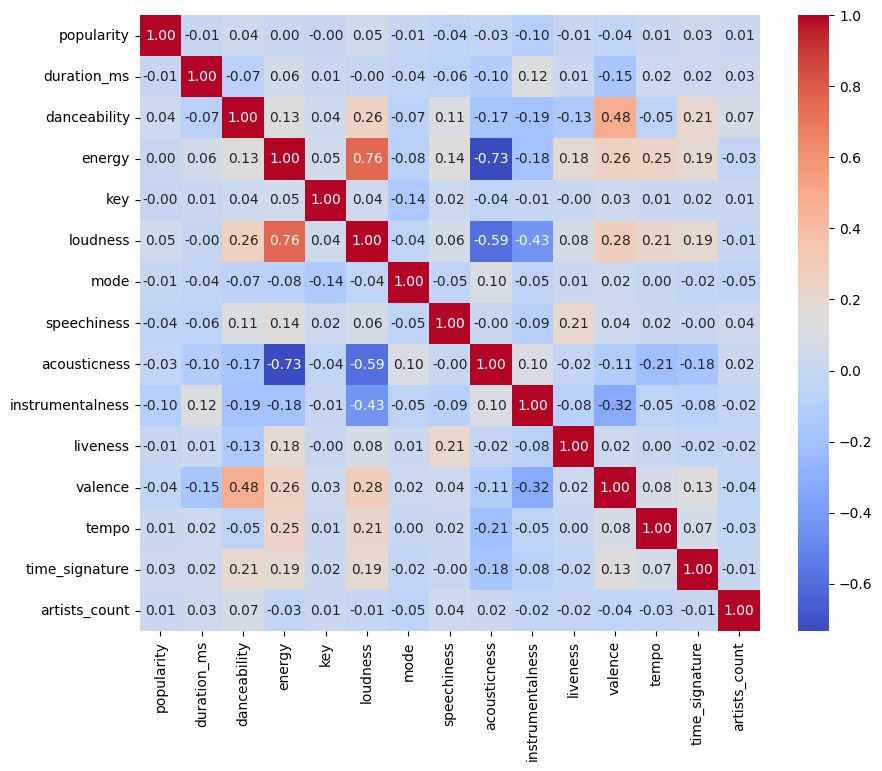

In [44]:
# MIEJSCE NA TWÓJ KOD
spotify_numeric = spotify.select_dtypes(include=['number'])
corr_matrix = spotify_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

Najsilniejsza dodatnia korelacja występuje między *loudness* i *energy* (0.76), co świadczy, że głośniejsze utwory są zwykle bardziej energiczne. Natomiast najmocniej ujemnie skorelowane są *energy* i *acousticness* (-0.73), co oznacza, że utwory akustyczne są mniej energiczne. W obu przypadkach podczas redukcji wymiarów można rozważyć pozostawienie tylko wartości z tych par.

Umiarkowane wartości korelacji występują między *valence* i *danceability* (dodatnia) oraz *acousticness* i *loudness* (ujemna). Pozostałe cechy i zależności mają niskie wartości korelacji, co świadczy o ich potencjalnej niezależności.

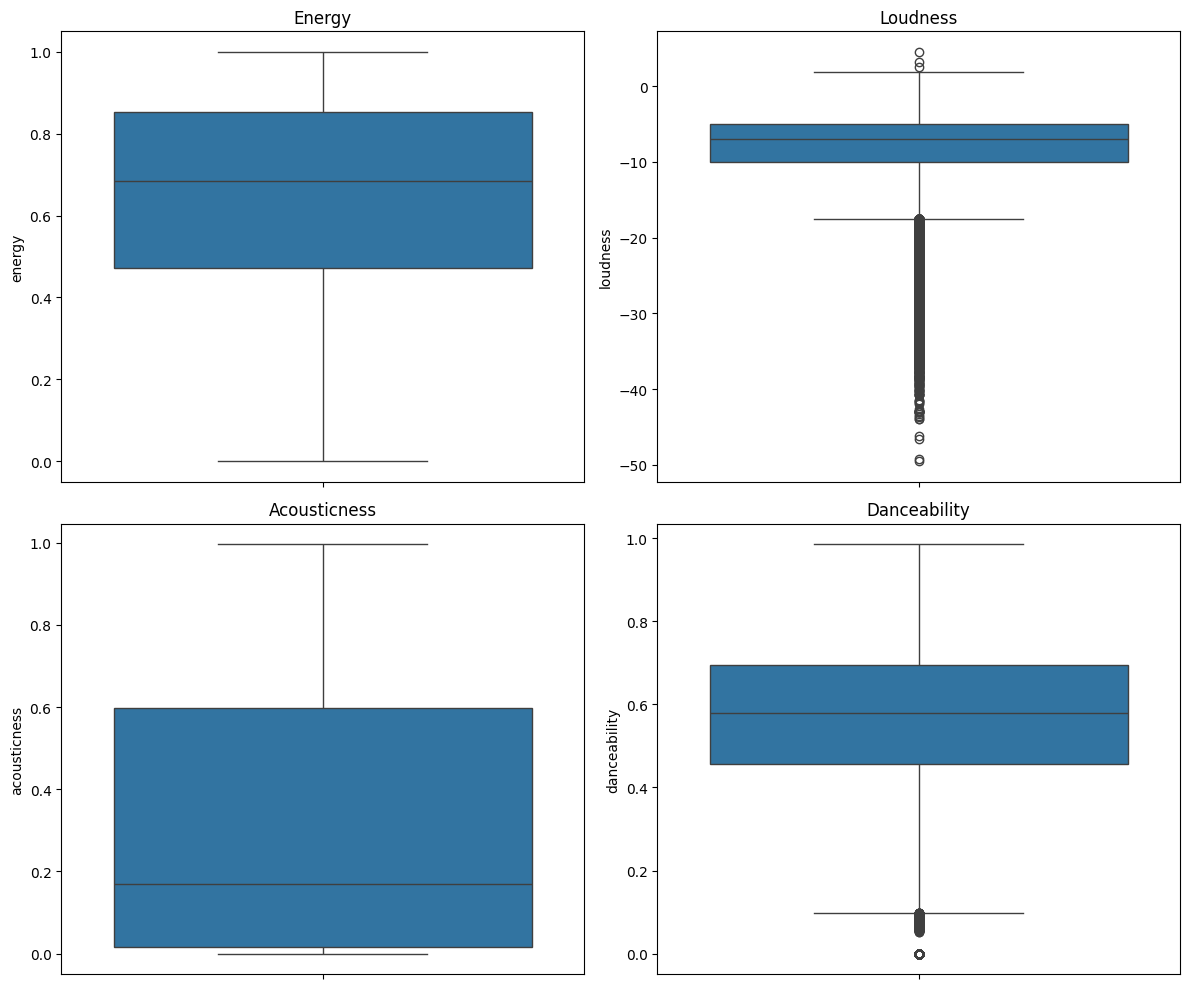

In [45]:
plt.figure(figsize=(12,10))

plt.subplot(2, 2, 1)
sns.boxplot(y=spotify['energy'])
plt.title("Energy")

plt.subplot(2, 2, 2)
sns.boxplot(y=spotify['loudness'])
plt.title("Loudness")

plt.subplot(2, 2, 3)
sns.boxplot(y=spotify['acousticness'])
plt.title("Acousticness")

plt.subplot(2, 2, 4)
sns.boxplot(y=spotify['danceability'])
plt.title("Danceability")

plt.tight_layout()
plt.show()

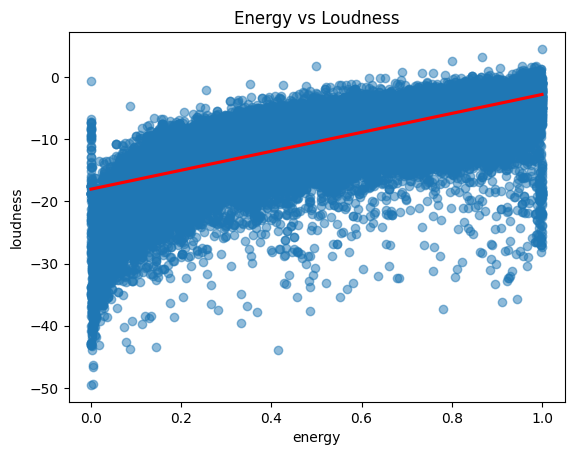

In [46]:
sns.regplot(data=spotify, x='energy', y='loudness', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Energy vs Loudness")
plt.show()

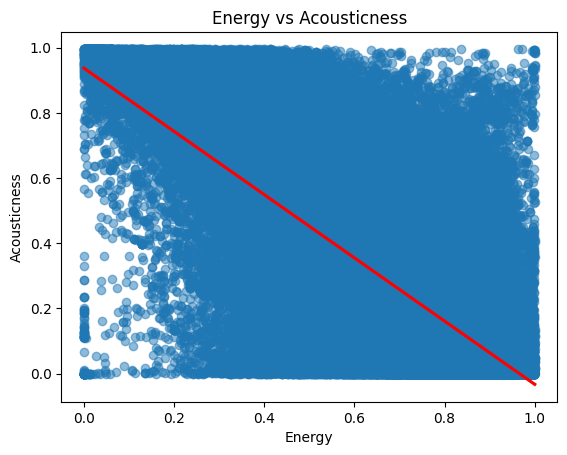

In [47]:
sns.regplot(data=spotify, x='energy', y='acousticness', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Energy vs Acousticness")
plt.xlabel("Energy")
plt.ylabel("Acousticness")
plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [48]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [49]:
# MIEJSCE NA TWÓJ KOD
spotify['key_name'] = spotify['key'].map(key_map)
spotify['mode_name'] = spotify['mode'].map({0: 'Minor', 1: 'Major'})
spotify['emotion'] = spotify.apply(lambda row: emotion_map[(row['key_name'], row['mode_name'])], axis=1)
spotify.drop(columns=['key_name', 'mode_name'], inplace=True)
spotify

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,artists_count,emotion
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,1,Melancholic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,1,Joyful
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,2,Happy
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,1,Happy
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,1,Triumphant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,1,Passionate
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,1,Sad
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,1,Sad
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,1,Rustic


## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [50]:
# MIEJSCE NA TWÓJ KOD
# usuwam loudness w związku z silną koleralcją z energy
spotify_filtered = spotify.drop(columns=['loudness'])

#oddzielam cechy kategoryczne od numerycznych
categorical_cols = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'emotion']
spotify_num = spotify_filtered.drop(columns=categorical_cols, errors='ignore')

#zmieniam explicit z bool na 0-1
if 'explicit' in spotify_num.columns:
    spotify_num['explicit'] = spotify_num['explicit'].astype(int)

print("Wariancja poszczególnych cech:")
print(spotify_num.var().sort_values())

Wariancja poszczególnych cech:
speechiness         1.117943e-02
danceability        3.011711e-02
liveness            3.624382e-02
energy              6.326740e-02
valence             6.721630e-02
explicit            7.819106e-02
instrumentalness    9.582484e-02
acousticness        1.105711e-01
time_signature      1.871624e-01
mode                2.310798e-01
artists_count       7.457101e-01
key                 1.267359e+01
popularity          4.975112e+02
tempo               8.986979e+02
duration_ms         1.151244e+10
dtype: float64


Tak jak wspominałem przy okazji macierzy korelacji, usunąłem *loudness* z powodu wysokiej korelacji z *energy*. Wymieniłem wartości w *explicit* z `bool` na 0-1. Na koniec sprawdziłem wariancję danych numerycznych, na podstawie czego można zauważyć sporą różnicę w skali i możemy wnioskować konieczność użycia standaryzacji przed PCA.

### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [52]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ["duration_ms", "explicit", "danceability", "energy","key", "mode", "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature", "artists_count"]

print("--- METODA WRAPPER ---")
print("1. Obliczanie dokładności bazowej...")
base_acc = classify(spotify, example_feats)
print(f"\n=> Dokładność bazowa (wszystkie badane cechy): {base_acc:.4f}\n")

features_to_drop_wrapper = []

print("2. Testowanie usuwania poszczególnych cech...")
for feat in example_feats:
    test_feats = [f for f in example_feats if f != feat]

    acc = classify(spotify, test_feats)

    if acc >= base_acc:
        print(f"[ DO USUNIĘCIA ] '{feat}' -> Wynik: {acc:.4f} (>= {base_acc:.4f})")
        features_to_drop_wrapper.append(feat)
    else:
        print(f"[ DO ZOSTAWIENIA ] '{feat}' -> Wynik spadł do: {acc:.4f}")

print(f"\nPodsumowanie Wrappera:")
print(f"Cechy zakwalifikowane do ostatecznego usunięcia: {features_to_drop_wrapper}")

--- METODA WRAPPER ---
1. Obliczanie dokładności bazowej...
Features  : ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'artists_count']
Test Acc  : 0.6054

=> Dokładność bazowa (wszystkie badane cechy): 0.6054

2. Testowanie usuwania poszczególnych cech...
Features  : ['explicit', 'danceability', 'energy', 'key', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'artists_count']
Test Acc  : 0.6042
[ DO ZOSTAWIENIA ] 'duration_ms' -> Wynik spadł do: 0.6042
Features  : ['duration_ms', 'danceability', 'energy', 'key', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'artists_count']
Test Acc  : 0.6100
[ DO USUNIĘCIA ] 'explicit' -> Wynik: 0.6100 (>= 0.6054)
Features  : ['duration_ms', 'explicit', 'energy', 'key', 'mode', 'speechiness', 'acousticness',

Na podstawie *wrappera*, możemy odrzucić aż 8 cech: `['explicit', 'key', 'mode', 'acousticness', 'liveness', 'tempo', 'time_signature', 'artists_count']`. Domyślam się, że nie jest to najlepszy sposób, ponieważ usuwając jedną cechę układ zależności mógłby się zmienić, przez co istnieje możliwość nieusuwania innej z tych cech. (Jednak na potrzeby wizualizacji nie usunąłem *explicit*)

### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [53]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing

In [54]:
from math import e
# przykładowe funkcje

def dataframe_xy(df, target_col):
    cols_to_drop = ['loudness', 'key', 'mode', 'acousticness', 'liveness', 'tempo', 'time_signature', 'artists_count']
    df = df.drop(columns=cols_to_drop, errors='ignore')

    y = df[target_col].values
    df_num = df.select_dtypes(include=['number'])
    if target_col in df_num.columns:
        df_num = df_num.drop(columns=[target_col])

    X = df_num.values
    return X, y

# normalize to [0,1] range
def normalize(X):
    return preprocessing.normalize(X, axis=0, norm='max')

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    return preprocessing.StandardScaler().fit_transform(X)

# remove outliers
def remove_outliers(X, y):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    std[std == 0] = 1
    z = np.abs((X - mean) / std)
    mask = (z < 3).all(axis=1)
    return X[mask], y[mask]



Analiza i wizualizacja dla kolumny docelowej: 'popularity_bracket'
Dane po usunięciu wartości odstających: 2890 (odrzucono 110 próbek)


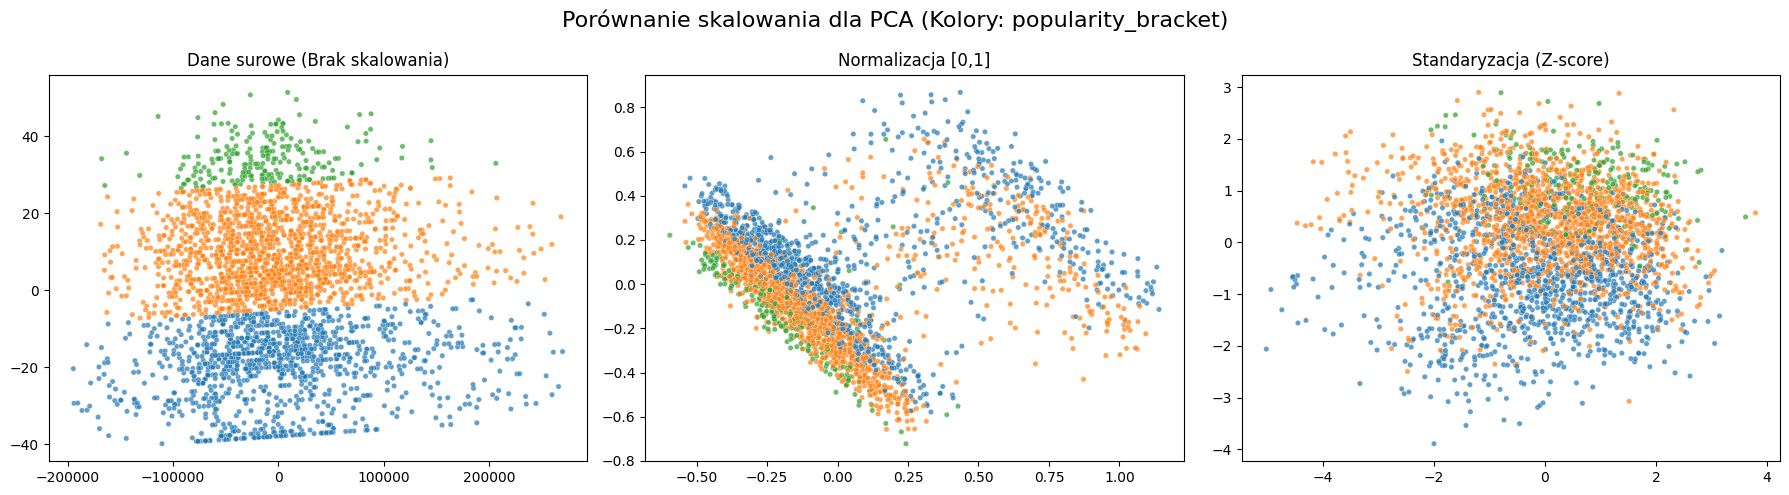

Trwa obliczanie mapy t-SNE dla 'popularity_bracket'... (może to zająć kilkadziesiąt sekund)



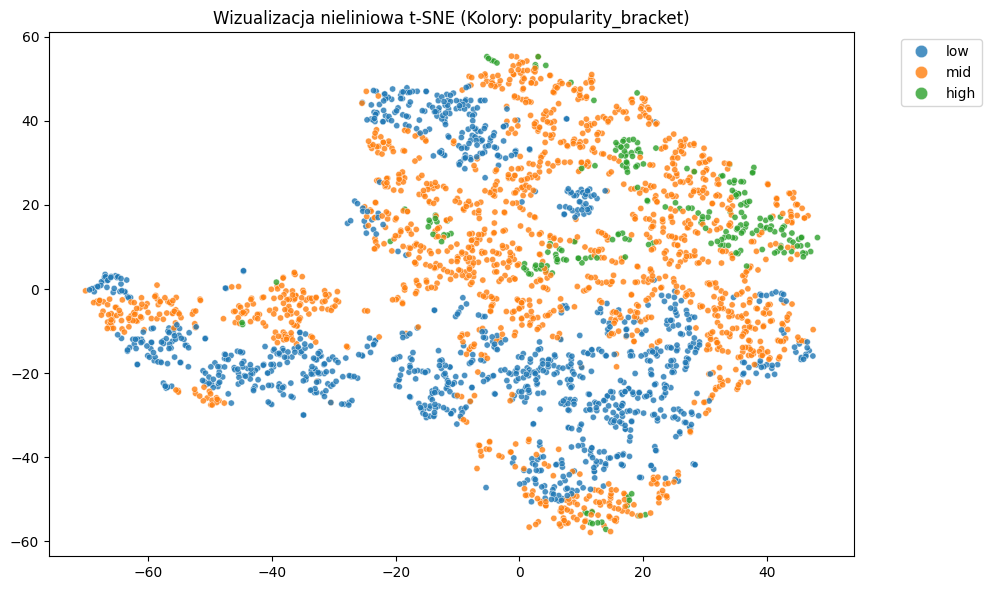


Analiza i wizualizacja dla kolumny docelowej: 'emotion'
Dane po usunięciu wartości odstających: 2909 (odrzucono 91 próbek)


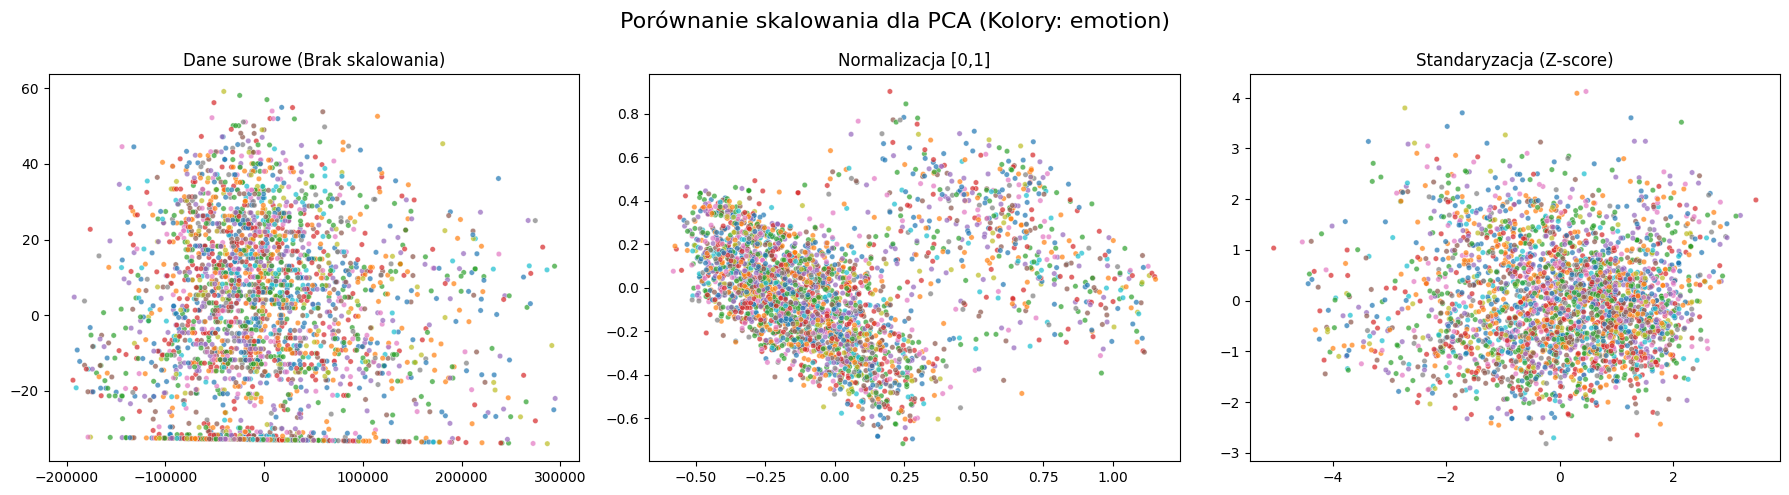

Trwa obliczanie mapy t-SNE dla 'emotion'... (może to zająć kilkadziesiąt sekund)



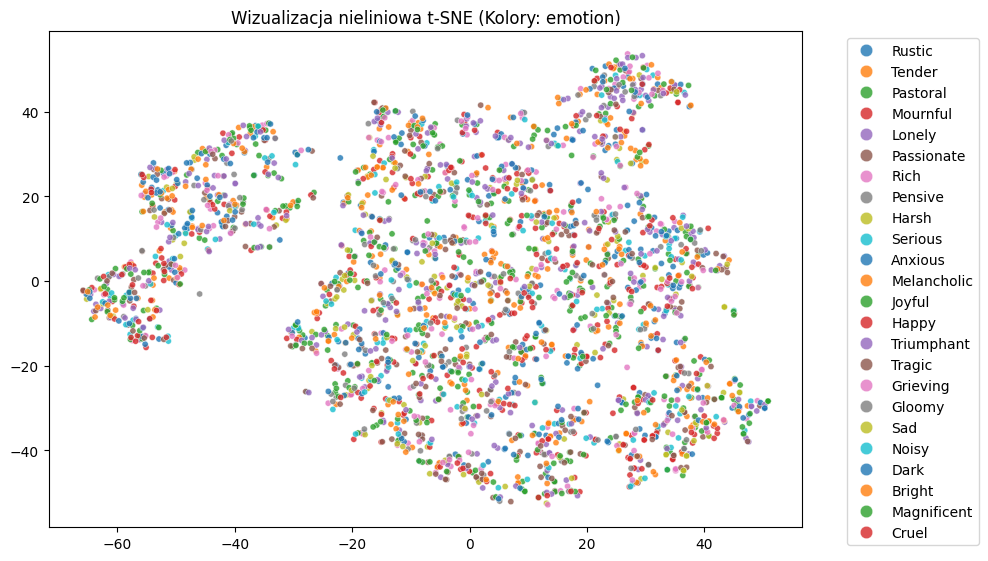


Analiza i wizualizacja dla kolumny docelowej: 'explicit'
Dane po usunięciu wartości odstających: 2909 (odrzucono 91 próbek)


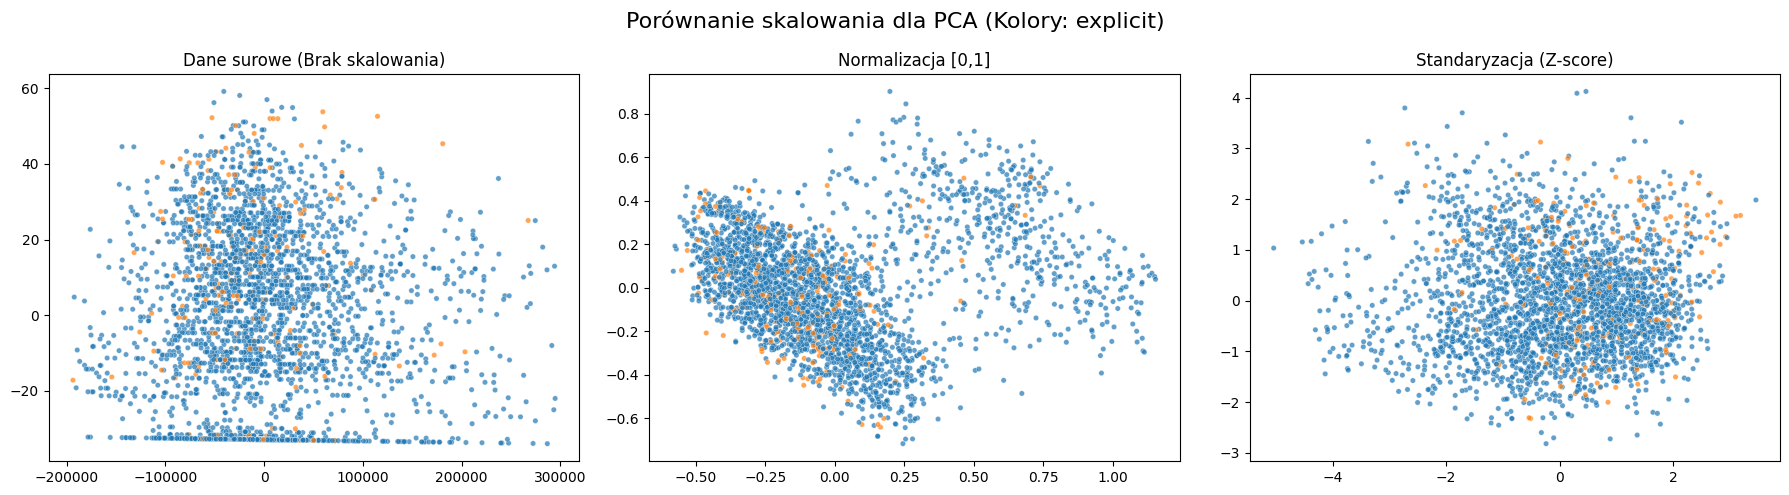

Trwa obliczanie mapy t-SNE dla 'explicit'... (może to zająć kilkadziesiąt sekund)



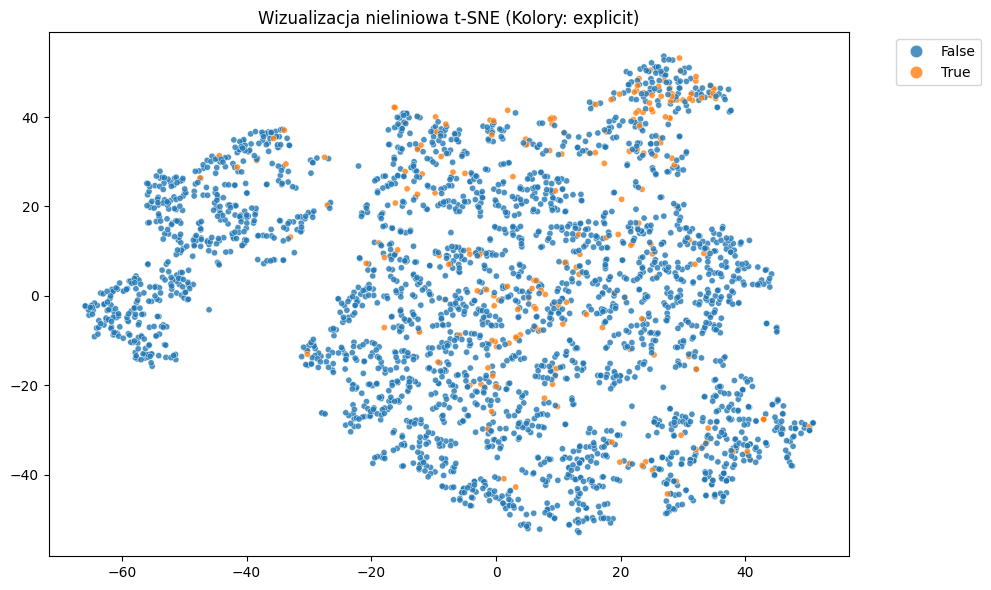

In [55]:
spotify["popularity_bracket"] = pd.cut(spotify["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
target_columns = ['popularity_bracket', 'emotion', 'explicit']

for target_col in target_columns:
    print(f"\n{'='*50}")
    print(f"Analiza i wizualizacja dla kolumny docelowej: '{target_col}'")
    print(f"{'='*50}")

    # Pobieramy próbkę 3000 wierszy, aby t-SNE nie "zacięło" Twojego komputera,
    # i upewniamy się, że nie ma braków w kolumnie docelowej.
    df_sample = spotify.dropna(subset=[target_col]).sample(n=3000, random_state=42)

    # 1. Podział na X i y (Twoja funkcja)
    X, y = dataframe_xy(df_sample, target_col)

    # 2. Usuwanie wartości odstających (Twoja funkcja)
    X_clean, y_clean = remove_outliers(X, y)
    print(f"Dane po usunięciu wartości odstających: {len(X_clean)} (odrzucono {len(X) - len(X_clean)} próbek)")

    # 3. Skalowanie danych (Twoje funkcje)
    X_norm = normalize(X_clean)
    X_std = standarize(X_clean)

    # ================= WIZUALIZACJA PCA =================
    pca = PCA(n_components=2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Porównanie skalowania dla PCA (Kolory: {target_col})', fontsize=16)

    sns.scatterplot(x=pca.fit_transform(X_clean)[:, 0], y=pca.fit_transform(X_clean)[:, 1],
                    hue=y_clean, ax=axes[0], palette='tab10', s=15, alpha=0.7, legend=False)
    axes[0].set_title('Dane surowe (Brak skalowania)')

    sns.scatterplot(x=pca.fit_transform(X_norm)[:, 0], y=pca.fit_transform(X_norm)[:, 1],
                    hue=y_clean, ax=axes[1], palette='tab10', s=15, alpha=0.7, legend=False)
    axes[1].set_title('Normalizacja [0,1]')

    sns.scatterplot(x=pca.fit_transform(X_std)[:, 0], y=pca.fit_transform(X_std)[:, 1],
                    hue=y_clean, ax=axes[2], palette='tab10', s=15, alpha=0.7, legend=False)
    axes[2].set_title('Standaryzacja (Z-score)')

    plt.tight_layout()
    plt.show()

    # ================= WIZUALIZACJA t-SNE =================
    # Algorytm t-SNE najlepiej radzi sobie na danych poddanych standaryzacji
    print(f"Trwa obliczanie mapy t-SNE dla '{target_col}'... (może to zająć kilkadziesiąt sekund)\n")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X_std)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_clean, palette='tab10', s=20, alpha=0.8)
    plt.title(f'Wizualizacja nieliniowa t-SNE (Kolory: {target_col})')
    # Legenda ląduje po prawej stronie, żeby nie zasłaniać chmury punktów
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
    plt.tight_layout()
    plt.show()